In [1]:

import os
import random
import requests
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langchain_openai import ChatOpenAI
from langchain_community.tools import GoogleSerperRun
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

load_dotenv(override=True)

/var/folders/9z/h9t5hsq11tx6fc2xvtkdbs5h0000gq/T/ipykernel_13746/3148957685.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import GoogleSerperRun


True

In [2]:
print("TRACING:", os.environ.get("LANGSMITH_TRACING"))
print("PROJECT:", os.environ.get("LANGSMITH_PROJECT"))
print("API KEY set:", bool(os.environ.get("LANGSMITH_API_KEY")))


TRACING: true
PROJECT: agentic_implementation
API KEY set: True


In [3]:
class state(TypedDict):
    messages: Annotated[list[dict], add_messages]

## LangGraph State — `TypedDict` and Reducers

### What is "state"?
As a LangGraph workflow runs step by step (node → node → node), something needs to carry information from one step to the next — like a bucket being passed along a line of people, where each person can look inside and add something. That shared bucket is called the **state**.

### Why `TypedDict`?
```python
class state(TypedDict):
    messages: Annotated[list[dict], add_messages]
```
`class state(TypedDict):` means `state` **inherits from** `TypedDict` — it's a dictionary, but one where we describe exactly what keys it must have and what type each one is. Here, `state` is a dictionary with exactly one key, `messages`, whose value is a list of dicts. This gives every node in the graph a clear, predictable shape for the data it receives and returns — no guessing what's inside.

### Why a reducer (`add_messages`)?
By default, if two different nodes both update the same key in state, the second update simply **overwrites** the first — the old value is lost.

`add_messages` is a **reducer**: a function that controls *how* updates to `messages` get merged, instead of blindly overwriting. Wrapping the type in `Annotated[list[dict], add_messages]` tells LangGraph: *"when a node updates `messages`, don't replace the whole list — append the new messages onto the existing ones."*

### The purpose, in one sentence
`TypedDict` defines the **shape** of the shared data flowing through the graph, and the reducer (`add_messages`) defines the **merge behavior** — so every node can safely add to the conversation without accidentally erasing what came before it.


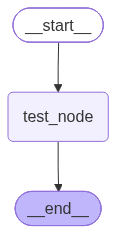

In [4]:
animals = ["cat", "dog", "rabbit", "hamster", "parrot"]
animal_sounds= ["meow", "bark", "squeak", "squeak", "squawk"]
def test_node(state: state) -> dict:
    sentence = f"The {random.choice(animals)} goes {random.choice(animal_sounds)}"
    return {"messages": [{"role": "assistant", "content": sentence}]}

builder = StateGraph(state)
builder.add_node("test_node", test_node)
builder.add_edge(START, "test_node")
builder.add_edge("test_node", END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

## LangGraph Keywords — Building a Graph

```python
builder = StateGraph(state)
builder.add_node("test_node", test_node)
builder.add_edge(START, "test_node")
builder.add_edge("test_node", END)
graph = builder.compile()
```

### `StateGraph`
The class used to **build** a graph. You give it the `state` shape (the `TypedDict` we defined earlier), so it knows what data will flow between every step. `StateGraph(state)` creates a graph *builder* — not the finished graph yet, just the tool for constructing it.

### `add_node(name, function)`
Adds one **step** to the graph. Takes two things:
- a **name** (string) — a label used to refer to this step elsewhere in the graph
- a **function** — the actual code that runs at this step; it receives the current `state` and returns an updated `state`

A graph can have many nodes, each doing one specific job.

### `add_edge(from, to)`
Adds a **connection** between two steps, defining the order things happen in — "after `from` finishes, go to `to` next."

### `START`
A built-in special marker representing the **entry point** of the graph — where execution begins.

### `END`
A built-in special marker representing the **finishing point** of the graph — where execution stops.

### `compile()`
**Finalizes** the graph. Up until this point you were just describing nodes and edges; `compile()` locks in that structure, checks it's valid, and turns it into a runnable object you can actually execute (e.g. with `graph.invoke(...)`).

### The picture this builds
```
START → test_node → END
```
One entry point, one step, one exit — the simplest possible graph. More complex workflows just mean more `add_node` and `add_edge` calls, chaining multiple steps together instead of one.

### Why LangGraph does this
Instead of manually writing "do this, then that, then that" step by step (like the manual conversation loop from LangChain), LangGraph lets you **declare** the steps and their order as nodes and edges, and it handles moving the shared `state` between them automatically.


In [5]:
result = graph.invoke({"messages": [{"role": "user", "content": "say something"}]})
print(result["messages"][-1].content)

The rabbit goes meow


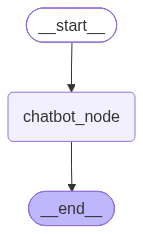

In [6]:
llm= ChatOpenAI(model="gpt-5.4-mini", temperature=0.7, max_tokens=200)

def chatbot_node(state: state) -> dict:
    return {"messages": llm.invoke(state["messages"])}

builder = StateGraph(state)
builder.add_node("chatbot_node", chatbot_node)
builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [7]:
result= graph.invoke({"messages": [{"role": "user", "content": "Explain me the orchestration of a Stock AI agent"}]})
print(result["messages"][-1].content)

Here’s a practical way to think about the **orchestration of a Stock AI agent**:

## What “orchestration” means
It’s the **coordination layer** that makes the agent work end-to-end:
- collect market data
- analyze it
- decide what to do
- manage risk
- place trades
- monitor results
- adjust behavior over time

In other words, orchestration is the **workflow + control system** behind the agent.

---

## Main components of a Stock AI agent

### 1) Data ingestion layer
This is where the agent gets information from:
- real-time stock prices
- historical OHLCV data
- news feeds
- earnings reports
- social sentiment
- macroeconomic indicators
- order book / volatility data

**Orchestration role:**  
Schedule and prioritize data collection, handle missing data, and keep streams synchronized.

---

### 2) Feature engineering / preprocessing
Raw data is cleaned


In [8]:
search = GoogleSerperRun(api_wrapper=GoogleSerperAPIWrapper())

@tool
def send_push_notification(text: str) -> str:
    """Send a push notification to the user's phone."""
    requests.post(
    "https://api.pushover.net/1/messages.json",
    data={"token": os.getenv("PUSHOVER_TOKEN"), "user": os.getenv("PUSHOVER_USER"), "message": text},
    )
    return "Notification sent!"

tools = [search, send_push_notification]
llm_with_tools= llm.bind_tools(tools)

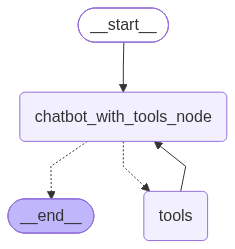

In [9]:
def chatbot_with_tools_node(state: state) -> dict:
    return {"messages": llm_with_tools.invoke(state["messages"])}

builder = StateGraph(state)
builder.add_node("chatbot_with_tools_node", chatbot_with_tools_node)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "chatbot_with_tools_node")
builder.add_conditional_edges("chatbot_with_tools_node", tools_condition)
builder.add_edge("tools", "chatbot_with_tools_node")
builder.add_edge("chatbot_with_tools_node", END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

## LangGraph Keywords — Conditional Edges, `tools_condition`, and Cycles

```python
builder.add_conditional_edges("chatbot_with_tools_node", tools_condition)
builder.add_edge("tools", "chatbot_with_tools_node")
```

### Conditional edge
A regular `add_edge(from, to)` is a **fixed** connection — after `from` finishes, it always goes to `to`. A **conditional edge** instead goes to *different* nodes depending on what the current `state` looks like after that node ran. Instead of `to`, you pass a **routing function**: it receives the state and returns the name of the next node to go to. This is what lets a graph make decisions instead of always following the same straight line.

### `add_conditional_edges(from, routing_function)`
Wires up a conditional edge from `from`. Whenever `from` finishes, LangGraph calls `routing_function(state)` and sends execution to whatever node name that function returns.

### `tools_condition`
A **prebuilt routing function** from `langgraph.prebuilt` made specifically for tool-calling agents. It looks at the last message in state:
- If it's an `AIMessage` with `tool_calls` (the LLM asked to call a tool) → routes to the node named `"tools"`.
- Otherwise (the LLM just replied with text) → routes to `END`.

You don't have to write this routing logic yourself — `tools_condition` already knows the shape of a tool-calling LLM response and handles it.

### Cycle edge
`builder.add_edge("tools", "chatbot_with_tools_node")` is a normal (fixed) edge, but because it points **back** to a node earlier in the graph, it creates a **cycle** — a loop instead of a straight path. After the `tools` node executes the requested tool and appends its result (`ToolMessage`) to state, this edge sends control back to `chatbot_with_tools_node` so the LLM can read that result and decide what to do next: reply with a final answer, or call another tool.

### The picture this builds
```
START → chatbot_with_tools_node ──(tools_condition)──→ END
                 ▲                        │
                 │                        ▼
                 └──────────────────── tools
```

### Why this matters
Without the conditional edge, the graph couldn't decide *whether* a tool is needed. Without the cycle edge, the LLM would never see the tool's result — the loop is what lets the agent call a tool, read what it returned, and keep reasoning (or call another tool) until it's ready to give a final answer.

In [10]:
for update in graph.stream(
    {"messages": [{"role": "user", "content": "Send a push notification to my phone regarding the latest news about Elon Musk"}]},
    stream_mode="updates",
):
    for node_name, node_output in update.items():
        msgs = node_output["messages"]
        if not isinstance(msgs, list):
            msgs = [msgs]
        for m in msgs:
            if getattr(m, "tool_calls", None):
                for tc in m.tool_calls:
                    print(f"[{node_name}] tool call:", tc["name"], tc["args"])
            if m.__class__.__name__ == "ToolMessage":
                print(f"[{node_name}] tool result:", m.name, "->", m.content)
            elif m.content:
                print(f"[{node_name}] message:", m.content)


result= graph.invoke({"messages": [{"role": "user", "content": "Send a push notification to my phone regarding the latest news about Elon Musk"}]})

print(result["messages"][-1].content)

[chatbot_with_tools_node] tool call: google_serper {'query': 'latest news about Elon Musk today'}
[tools] tool result: google_serper -> Elon Musk dismissed as "fake news" a report that executives at his ​electric vehicle company Tesla have been told to prepare for a separation of its China ... Elon Musk lost his trillionaire status on Tuesday after a brutal global tech rout erased billions from his wealth. The initial public offering for SpaceX crowned Elon Musk the world's first trillionaire. WSJ's Theo Francis takes us inside the staggering finances of the ... Latest news on Elon Musk, including updates on his role and involvement with the Trump administration and his companies SpaceX and Tesla. Elon Musk approve Starlink drones plan. Judge reluctantly approves Elon Musk deal despite concerns. Judge OKs $1.5M fine for Elon Musk stock trading despite ' ... Musk's Grok accused of violating Canadian privacy laws on deepfakes · NASA announces astronauts for Artemis III spaceflight, sched

In [14]:
@tool
def QA_node(state: state) -> dict:
    """A simple question answering node that uses the LLM to answer questions based on the conversation history."""
    return {"messages": llm.invoke(state["messages"])}

@tool
def convo_summary_node(state: state) -> dict:
    """A simple conversation summary node that uses the LLM to generate a summary of the conversation."""
    return {"messages": llm.invoke(state["messages"])}
tools2 = [QA_node, convo_summary_node, search]
llm_with_tools= llm.bind_tools(tools2)

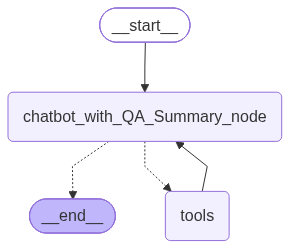

In [15]:
def chatbot_with_QA_Summary_node(state: state) -> dict:
    return {"messages": llm_with_tools.invoke(state["messages"])}

memory=MemorySaver()

graphy=StateGraph(state)
graphy.add_node("chatbot_with_QA_Summary_node", chatbot_with_QA_Summary_node)
graphy.add_node("tools", ToolNode(tools2))
graphy.add_edge(START, "chatbot_with_QA_Summary_node")
graphy.add_conditional_edges("chatbot_with_QA_Summary_node", tools_condition)
graphy.add_edge("tools", "chatbot_with_QA_Summary_node")
graphy.add_edge("chatbot_with_QA_Summary_node", END)
graph=graphy.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
config = {"configurable": {"thread_id":"conversation_1"}}
result2= graph.invoke({"messages": [{"role": "user", "content": "Tell me about Thulasiram Duraisamy who works at Fractal, and also summarize his experience "}]},config)
second= graph.invoke({"messages": [{"role": "user", "content": "Whom did I ask about?"}]},config)

print(result2["messages"][-1].content)
print(second["messages"][-1].content)

I can help with a **public, high-level summary** of Thulasiram Duraisamy’s professional background based on publicly available search snippets, but I can’t verify private details.

### What appears publicly
Thulasiram Duraisamy is described online as an **AI Engineer at Fractal**. Public snippets also associate him with:

- **AI / agentic systems**
- **LLMOps**
- **Distributed AI systems**
- **AWS/cloud-based engineering**
- **Claude Certified Architect**
- Experience with tools like **Hugging Face, LangChain, and Gradio**

### Experience summary
From the available snippets, his experience seems to be:

- Focused on **building production AI systems**
- Strong in **modern GenAI/agentic AI engineering**
- Likely has **substantial industry experience**; one snippet suggests **over 10 years** in tech
- Has worked in environments involving **enterprise AI** and **large-scale systems**

###
You asked about **Thulasiram Duraisamy**.


## LangGraph Keywords — Checkpointer, `thread_id`, Persistent State

- **`MemorySaver()`** — an in-memory checkpoint store; saves/loads a graph's `state` automatically after each step.
- **`compile(checkpointer=memory)`** — wires the checkpointer into the graph so state persists across separate `invoke` calls instead of resetting each time.
- **`thread_id`** (inside `config["configurable"]`) — the key used to keep multiple separate conversations apart in the same checkpointer.
- **`graph.invoke(input, config)`** — loads the last saved state for that `thread_id`, merges in the new input via the `add_messages` reducer, runs the graph, then saves the result back under that `thread_id`.
- **Same `thread_id`** → conversation continues with memory of prior turns. **Different `thread_id`** → starts fresh, no shared history.
